# Fraud Detection using Machine Learning

## Project Objective

The objective of this project is to detect fraudulent financial transactions using machine learning techniques. The project analyzes transaction patterns and builds predictive models to classify transactions as fraudulent or legitimate.

## Importing Required Libraries

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report)

## Data Loading

In [10]:
df = pd.read_csv("../data/creditcard.csv")

In [11]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## Exploratory Data Analysis

In [12]:
df.shape

(284807, 31)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

## Data Cleaning

In [14]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [15]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [16]:
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

## Fraud Distribution Analysis

C:\Users\User\AppData\Local\Temp\ipykernel_37348\1924125772.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Non-Fraud', 'Fraud'])


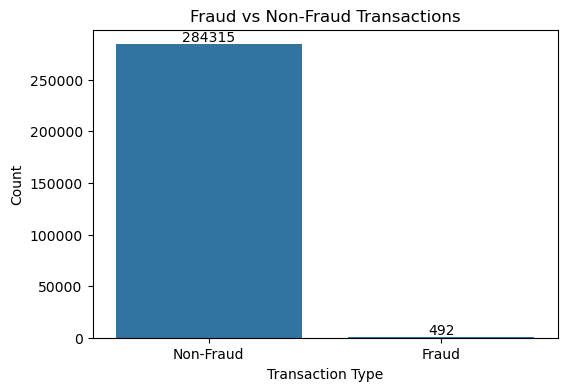

In [17]:
plt.figure(figsize=(6,4))

ax = sns.countplot(x='Class', data=df)

plt.title("Fraud vs Non-Fraud Transactions")
plt.xlabel("Transaction Type")
plt.ylabel("Count")

# Rename labels
ax.set_xticklabels(['Non-Fraud', 'Fraud'])

# Add values on bars
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom'
    )

plt.show()

### Insight

The dataset is highly imbalanced, where non-fraudulent transactions significantly outnumber fraudulent transactions.

## Fraud Percentage Visualization

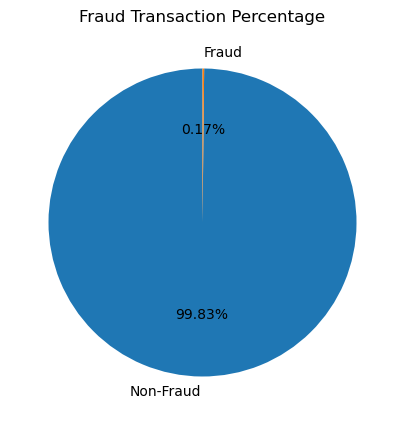

In [18]:
fraud_counts = df['Class'].value_counts()

plt.figure(figsize=(5,5))

plt.pie(
    fraud_counts,
    labels=['Non-Fraud', 'Fraud'],
    autopct='%1.2f%%',
    startangle=90
)

plt.title("Fraud Transaction Percentage")

plt.show()

### Insight

Fraudulent transactions represent only a very small percentage of total transactions.

## Feature Scaling

In [19]:
scaler = StandardScaler()

df['Amount'] = scaler.fit_transform(df[['Amount']])

In [20]:
X = df.drop('Class', axis=1)

y = df['Class']

### Why Scaling?

Feature scaling helps machine learning models perform better by normalizing feature values.

## Train-Test Split

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Model Training

## Logistic Regression

In [22]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

C:\Users\User\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

### Model Training Completed

## Decision Tree

In [23]:
from sklearn.tree import DecisionTreeClassifier
tree = DecisionTreeClassifier(max_depth=5)
tree.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5)

### Insight

Decision Trees help identify decision rules and transaction patterns effectively.

## Neural Network Model

In [24]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

nn = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])
nn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
nn.fit(X_train, y_train, epochs=10, batch_size=32)


C:\Users\User\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
7121/7121 ━━━━━━━━━━━━━━━━━━━━ 41s 5ms/step - accuracy: 0.9964 - loss: 7.5140 
Epoch 2/10
7121/7121 ━━━━━━━━━━━━━━━━━━━━ 37s 5ms/step - accuracy: 0.9977 - loss: 0.5815
Epoch 3/10
7121/7121 ━━━━━━━━━━━━━━━━━━━━ 42s 5ms/step - accuracy: 0.9981 - loss: 0.0457
Epoch 4/10
7121/7121 ━━━━━━━━━━━━━━━━━━━━ 40s 5ms/step - accuracy: 0.9983 - loss: 0.0284
Epoch 5/10
7121/7121 ━━━━━━━━━━━━━━━━━━━━ 42s 5ms/step - accuracy: 0.9983 - loss: 0.0242
Epoch 6/10
7121/7121 ━━━━━━━━━━━━━━━━━━━━ 41s 5ms/step - accuracy: 0.9983 - loss: 0.0141
Epoch 7/10
7121/7121 ━━━━━━━━━━━━━━━━━━━━ 37s 5ms/step - accuracy: 0.9983 - loss: 0.0812
Epoch 8/10
7121/7121 ━━━━━━━━━━━━━━━━━━━━ 40s 5ms/step - accuracy: 0.9983 - loss: 0.0372
Epoch 9/10
7121/7121 ━━━━━━━━━━━━━━━━━━━━ 41s 5ms/step - accuracy: 0.9982 - loss: 0.0212
Epoch 10/10
7121/7121 ━━━━━━━━━━━━━━━━━━━━ 37s 5ms/step - accuracy: 0.9983 - loss: 0.0147


### Insight

Neural Networks can learn complex fraud detection patterns from transaction data.

## Handling Class Imbalance using SMOTE

In [25]:
from imblearn.over_sampling import SMOTE
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_train, y_train)

In [26]:
y_pred = model.predict(X_test)

### Why SMOTE?

SMOTE helps balance the dataset by generating synthetic fraud transaction samples, improving model learning.

## Model Evaluation

In [27]:
accuracy_score(y_test, y_pred)

0.9990695551420246

## Confusion Matrix

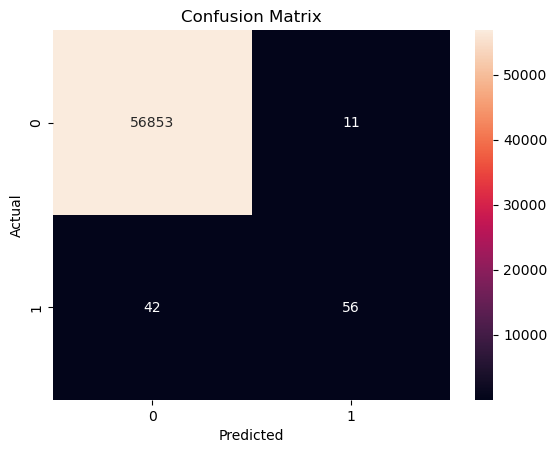

In [28]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')

plt.title("Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### Insight

The confusion matrix helps evaluate fraud detection performance by comparing predicted and actual values.

## Classification Report

In [18]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.70      0.56      0.62        98

    accuracy                           1.00     56962
   macro avg       0.85      0.78      0.81     56962
weighted avg       1.00      1.00      1.00     56962



### Key Metrics

- Precision measures prediction accuracy for fraud cases.
- Recall measures the model’s ability to detect fraud.
- F1-score balances precision and recall.

# Key Insights

1. Fraudulent transactions represent a very small portion of total transactions.
2. The dataset is highly imbalanced.
3. Machine learning models can effectively identify suspicious transaction patterns.
4. Recall is an important metric in fraud detection because identifying fraudulent activity is critical.

# Recommendations

1. Implement real-time fraud monitoring systems.
2. Use advanced machine learning models for improved fraud detection.
3. Continuously retrain models using updated transaction data.
4. Monitor high-risk transactions more aggressively.
5. Combine fraud detection systems with human verification for critical transactions.

# Conclusion

This project successfully applied machine learning techniques to detect fraudulent transactions. The analysis demonstrated how predictive models can help financial institutions identify suspicious activity and reduce financial risks through data-driven fraud detection systems.